In [1]:
#import packages

import numpy as np
import pandas as pd
import xarray as xr

import geopandas
import geodatasets

In [23]:
#this only needed if "pandas" does not import properly in the previous code cell
!pip install pandas

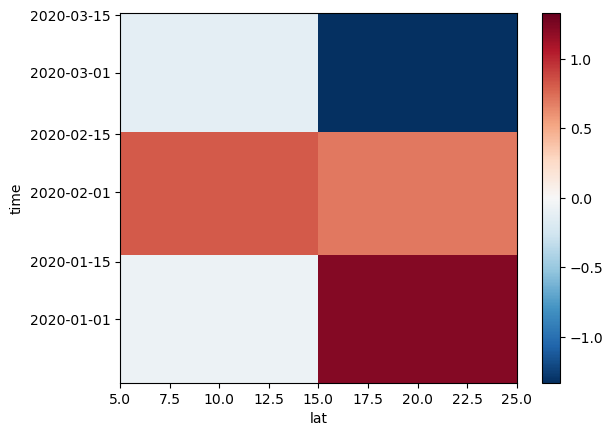

In [2]:
#simple array to ensure xarray works properly
data = xr.DataArray(
    np.random.randn(3,2,3),
    dims = ("time", "lat", "lon"),
    coords = {
        "lat": [10,20],
        "time": pd.date_range(
            "2020-01", periods = 3, freq = "MS"
        ),
    },
)

data[0,:]
data.loc[:,10]
data.isel(lat=0)
data.sel(time="2020-01")
data.mean(dim=["time", "lat"])
data.isel(lon=0).plot();

In [3]:
import rasterio
import rasterio.features
import rasterio.warp

In [4]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/bin/python3.10


In [6]:
#read coordinates of TIFF file
with rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif') as dataset:

    # Read the dataset's valid data mask as a ndarray.
    mask = dataset.dataset_mask()

    # Extract feature shapes and values from the array.
    for geom, val in rasterio.features.shapes(
            mask, transform=dataset.transform):

        # Transform shapes from the dataset's own coordinate
        # reference system to CRS84 (EPSG:4326).
        '''geom = rasterio.warp.transform_geom(
            dataset.crs, 'EPSG:4326', geom, precision=6)'''

        # Print GeoJSON shapes to stdout.
        print(dataset.crs)
        print(geom)

EPSG:4326
{'type': 'Polygon', 'coordinates': [[(-107.55192372387052, 33.89998227431894), (-107.55192372387052, 33.80215133817946), (-107.44588761244192, 33.80215133817946), (-107.44588761244192, 33.89998227431894), (-107.55192372387052, 33.89998227431894)]]}


In [7]:
#test rasterio with a set ECOSTRESS file
dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
dataset.name

'/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif'

In [6]:
#new_dataset = rasterio.open('/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif')
#new_dataset.name

'/Users/ryanjoshi/Desktop/MODIS S3 downloads/ECO3ETPTJPL.001_EVAPOTRANSPIRATION_PT_JPL_ETdaily_doy2022156184219_aid0001.tif'

In [8]:
dataset.count

1

In [9]:
dataset.width

168

In [10]:
dataset.height

155

In [11]:
dataset.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [12]:
from rasterio.transform import from_gcps
from rasterio.control import GroundControlPoint

In [13]:
#read the values of each pixel in a merged ET file
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240406_ET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 152.39233 161.00047       nan]
 [      nan       nan       nan ... 144.40862 168.88841       nan]
 [      nan       nan       nan ... 139.04951 144.65076 166.00804]]


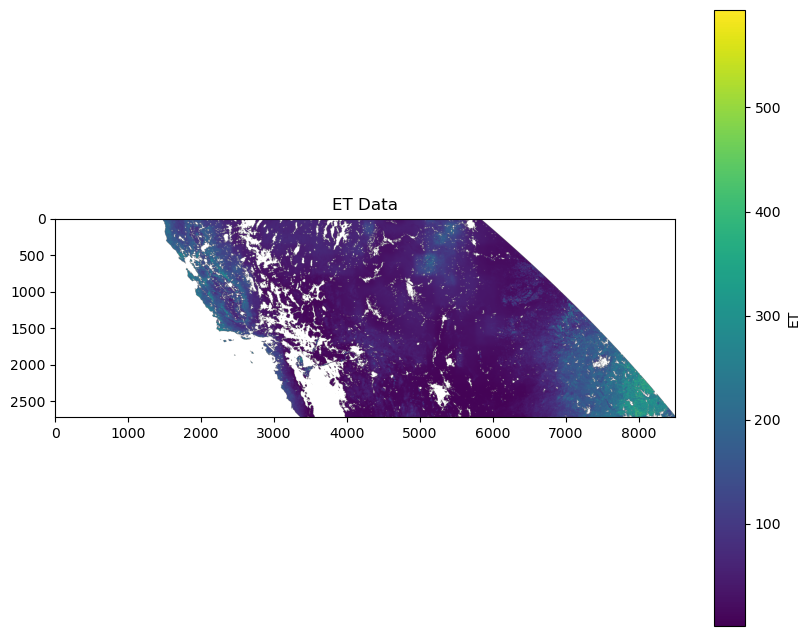

In [15]:
#plot the data from test_path in the previous cell
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [16]:
#read the values of each pixel in a merged ET file
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

[[      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 [      nan       nan       nan ...       nan       nan       nan]
 ...
 [      nan       nan       nan ... 405.08334 402.14795       nan]
 [      nan       nan       nan ... 402.9377  397.6011        nan]
 [      nan       nan       nan ... 403.94223 397.40744 402.252  ]]


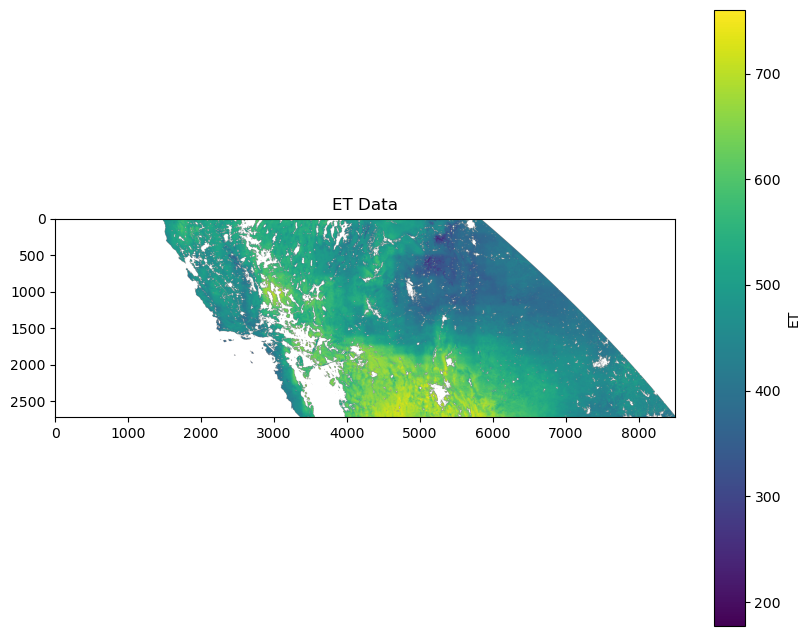

In [17]:
#plot the data from test_path in the previous cell
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [17]:
#this code cell does not run and was used for experimental purposes. use the next code cell to import os
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")

monthly_files = []

for filename in all_files:
    if "202405" in filename and "_ET" in filename:
        monthly_files.append(filename)

monthly_files

#better to rely on some kind of reference -- load an image, get the dimensions of that image, and compare that to everything else
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    data *= 0.000001

for file in monthly_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        data += src.read(1)
        data = np.where(data >= 32700, np.nan, data)
        #print(data)

data /= len(monthly_files)
print(data)


pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"
with rasterio.open(test_path) as src:
    pet_data = src.read(1)
    pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
    pet_data *= 0.000001

for file in pet_files:
    test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)

#each ET or PET file is an 8 day average
esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(esi_data)
plt.colorbar(label='ESI')
plt.title('ESI Data')
plt.show()

ValueError: operands could not be broadcast together with shapes (2725,8496) (1526,1345) (2725,8496) 

In [18]:
#use this code cell to import os
import os
all_files = os.listdir("/Users/ryanjoshi/Desktop/MODIS S3 downloads/")
all_files += os.listdir("/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024")

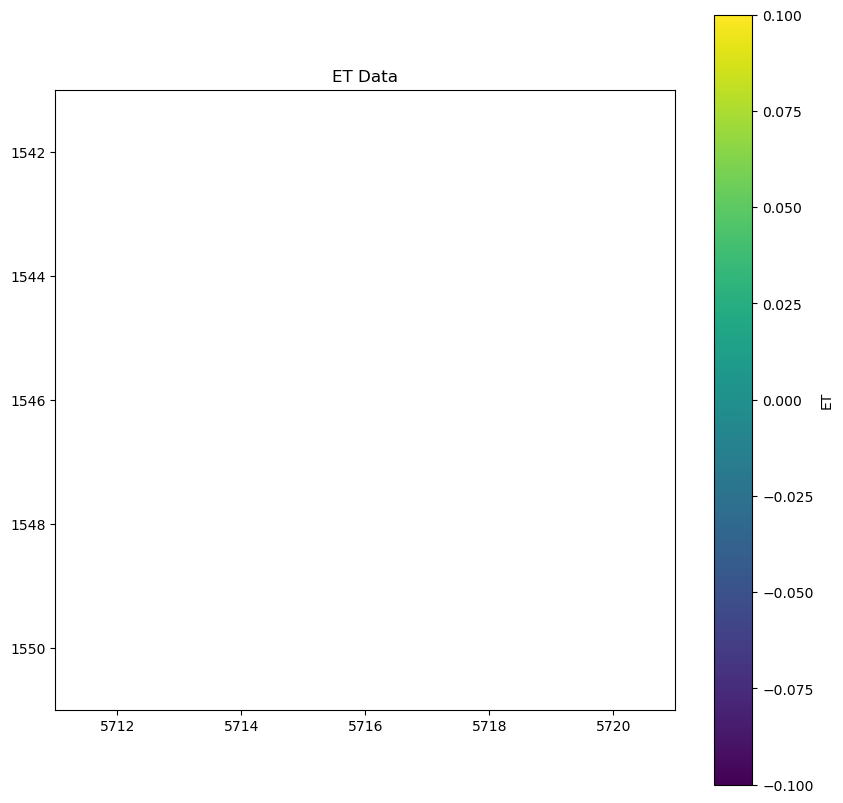

In [17]:
#this code cell returns a blank plot - ignore it if you want
test_path = "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_PET.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data > 54.5, np.nan, data)
    data = np.where(data < 54.1, np.nan, data)
    #print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.xlim(5711,5721)
plt.ylim(1551,1541)
plt.show()

In [25]:
#not needed unless there is a problem with running geopandas in the next code cell 
!pip install geopandas

In [19]:
import pandas as pd
import geopandas
import matplotlib.pyplot as plt
from geodatasets import get_path

In [20]:
import xarray
import rioxarray
from affine import Affine

In [154]:
#%pip install xarray==2025.6.1

ERROR: Could not find a version that satisfies the requirement xarray==2025.6.1 (from versions: 0.7.0, 0.7.1, 0.7.2, 0.8.0rc1, 0.8.0, 0.8.1, 0.8.2, 0.9.0rc1, 0.9.0, 0.9.1, 0.9.2, 0.9.3, 0.9.4, 0.9.5, 0.9.6, 0.10.0rc1, 0.10.0rc2, 0.10.0, 0.10.1, 0.10.2, 0.10.3, 0.10.4, 0.10.5, 0.10.6, 0.10.7, 0.10.8, 0.10.9, 0.11.0, 0.11.1, 0.11.2, 0.11.3, 0.12.0, 0.12.1, 0.12.2, 0.12.3, 0.13.0, 0.14.0, 0.14.1, 0.15.0, 0.15.1, 0.16.0, 0.16.1, 0.16.2, 0.17.0, 0.18.0, 0.18.1, 0.18.2, 0.19.0, 0.20.0, 0.20.1, 0.20.2, 0.21.0, 0.21.1, 2022.3.0, 2022.6.0rc0, 2022.6.0, 2022.9.0, 2022.10.0, 2022.11.0, 2022.12.0, 2023.1.0, 2023.2.0, 2023.3.0, 2023.4.0, 2023.4.1, 2023.4.2, 2023.5.0, 2023.6.0, 2023.7.0, 2023.8.0, 2023.9.0, 2023.10.0, 2023.10.1, 2023.11.0, 2023.12.0, 2024.1.0, 2024.1.1, 2024.2.0, 2024.3.0, 2024.5.0, 2024.6.0, 2024.7.0)
ERROR: No matching distribution found for xarray==2025.6.1
Note: you may need to restart the kernel to use updated packages.


In [21]:
#import xarray
xds = rioxarray.open_rasterio(
    "/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", 
    engine="rasterio")

In [158]:
#from affine import Affine

In [22]:
rds = rioxarray.open_rasterio("/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif", decode_coords="all")
rds.rio.crs

CRS.from_wkt('PROJCS["WGS 84 / Pseudo-Mercator",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Mercator_1SP"],PARAMETER["central_meridian",0],PARAMETER["scale_factor",1],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],EXTENSION["PROJ4","+proj=merc +a=6378137 +b=6378137 +lat_ts=0 +lon_0=0 +x_0=0 +y_0=0 +k=1 +units=m +nadgrids=@null +wktext +no_defs"],AUTHORITY["EPSG","3857"]]')

The next 5 code cells were used for troubleshooting and do not need to be run.

In [179]:
#import xarray as xr
#import gdal
print(rioxarray.__version__)

0.15.0


In [187]:
import pyproj
print(pyproj.__version__)

3.6.1


In [188]:
import pyproj
print(pyproj.__proj_version__)

9.3.0


In [244]:
import sys
print(sys.executable)

/usr/local/Caskroom/mambaforge/base/bin/python3.10


In [190]:
%pip install pyproj==3.7.1

ERROR: Could not find a version that satisfies the requirement pyproj==3.7.1 (from versions: 1.8.0, 1.8.1a0, 1.8.1, 1.9.3, 1.9.4, 1.9.5, 1.9.5.1, 1.9.6, 2.0.0, 2.0.1, 2.0.2, 2.1.0, 2.1.1, 2.1.2, 2.1.3, 2.2.0, 2.2.1, 2.2.2, 2.3.0, 2.3.1, 2.4.0, 2.4.1, 2.4.2, 2.4.2.post1, 2.5.0, 2.6.0, 2.6.1, 2.6.1.post1, 3.0rc2, 3.0.0, 3.0.0.post1, 3.0.1, 3.1.0, 3.2.0, 3.2.1, 3.3.0, 3.3.1, 3.4.0rc1, 3.4.0rc2, 3.4.0, 3.4.1rc0, 3.4.1, 3.5.0rc0, 3.5.0, 3.6.0rc0, 3.6.0, 3.6.1rc0, 3.6.1)
ERROR: No matching distribution found for pyproj==3.7.1
Note: you may need to restart the kernel to use updated packages.


In [23]:
#set the CRS to 4326
xda = xarray.DataArray(1)
xda.rio.write_crs(4326, inplace=True)
xda.spatial_ref

<xarray.DataArray 'spatial_ref' ()> Size: 8B
array(0)
Coordinates:
    spatial_ref  int64 8B 0
Attributes:
    crs_wkt:                      GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...
    semi_major_axis:              6378137.0
    semi_minor_axis:              6356752.314245179
    inverse_flattening:           298.257223563
    reference_ellipsoid_name:     WGS 84
    longitude_of_prime_meridian:  0.0
    prime_meridian_name:          Greenwich
    geographic_crs_name:          WGS 84
    horizontal_datum_name:        World Geodetic System 1984
    grid_mapping_name:            latitude_longitude
    spatial_ref:                  GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["...

In [24]:
xda.rio.crs

CRS.from_wkt('GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]')

In [25]:
rds.rio.write_crs(4326, inplace=True)
#rds.rio.set_spatial_dims(x_dim="lon", y_dim="lat", inplace=True)
rds.rio.write_coordinate_system(inplace=True)

#rds = rds.rename(x="longitude", y="latitude")

#rds = rds.rio.reproject("EPSG:4326")

<xarray.DataArray (band: 1, y: 2725, x: 8496)> Size: 93MB
[23151600 values with dtype=float32]
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 68kB -1.453e+07 -1.453e+07 ... -1.028e+07
  * y            (y) float64 22kB 4.866e+06 4.865e+06 ... 3.504e+06 3.504e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    _FillValue:     32700.0
    scale_factor:   1.0
    add_offset:     0.0

In [26]:
transform = Affine(3.0, 0.0, 466266.0, 0.0, -3.0, 8084700.0)
xda.rio.write_transform(transform, inplace=True)
xda.spatial_ref.GeoTransform

'466266.0 3.0 0.0 8084700.0 0.0 -3.0'

In [27]:
xda.rio.transform()

Affine(3.0, 0.0, 466266.0,
       0.0, -3.0, 8084700.0)

In [28]:
import urllib
import geojson

In [29]:
#set geometry to the outer bounds of New Mexico (if it were a square)
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.05, 36.999],
                 [-103, 36.999],
                [-103, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
cropped = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [44]:
#no need to run this code cell
import pyproj
print(pyproj.__proj_version__)

9.3.1


In [30]:
cropped

<xarray.DataArray (band: 1, y: 1526, x: 1347)> Size: 8MB
array([[[56.05772  , 56.702312 , 56.70582  , ..., 81.643105 ,
         81.7709   , 82.24886  ],
        [55.311386 , 55.770554 , 56.228333 , ..., 82.565765 ,
         82.62166  , 83.73735  ],
        [55.013046 , 55.254257 , 55.906826 , ..., 82.24882  ,
         82.425995 , 82.98256  ],
        ...,
        [13.702225 , 13.607969 , 14.792874 , ..., 15.7801075,
         17.137785 , 17.75787  ],
        [15.758725 , 14.838384 , 13.789731 , ..., 15.920914 ,
         17.08932  , 17.68497  ],
        [15.607399 , 17.527592 , 17.061396 , ..., 15.820736 ,
         17.021313 , 17.478968 ]]], shape=(1, 1526, 1347), dtype=float32)
Coordinates:
  * band         (band) int64 8B 1
  * x            (x) float64 11kB -1.214e+07 -1.214e+07 ... -1.147e+07
  * y            (y) float64 12kB 4.439e+06 4.438e+06 ... 3.677e+06 3.676e+06
    spatial_ref  int64 8B 0
Attributes:
    AREA_OR_POINT:  Area
    scale_factor:   1.0
    add_offset:     0.0
    _FillValue:     32700.0

In [31]:
#check to see whether there is an error regarding the number of dimensions

def valid_imshow_data(data):
    data = np.asarray(data)
    if data.ndim == 2:
        return True
    elif data.ndim == 3:
        if 3 <= data.shape[2] <= 4:
            return True
        else:
            print('The "data" has 3 dimensions but the last dimension '
                  'must have a length of 3 (RGB) or 4 (RGBA), not "{}".'
                  ''.format(data.shape[2]))
            return False
    else:
        print('To visualize an image the data must be 2 dimensional or '
              '3 dimensional, not "{}".'
              ''.format(data.ndim))
        return False

valid_imshow_data(cropped)

cropped.ndim

The "data" has 3 dimensions but the last dimension must have a length of 3 (RGB) or 4 (RGBA), not "1347".


3

In [32]:
#correct the error
if cropped.shape[0] == 1:
    cropped = cropped[0, :, :]

cropped.ndim

2

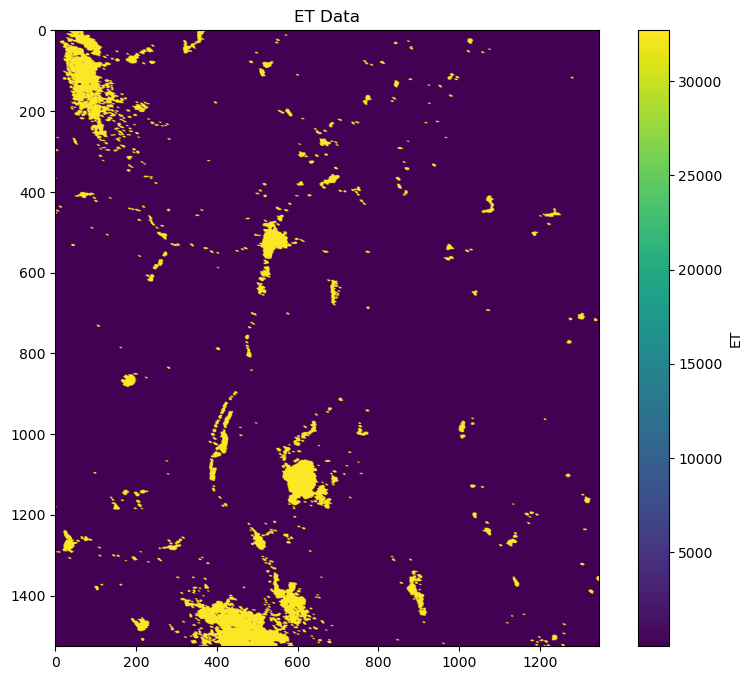

In [33]:
#plot the data for "square New Mexico"
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(cropped)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [34]:
#set the coordinates to a small portion of New Mexico
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-104.88, 34.45],
                [-104.84, 34.45],
                 [-104.84, 34.49],
                [-104.88, 34.49]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
beam = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [35]:
if beam.shape[0] == 1:
    beam = beam[0, :, :]

beam.ndim

2

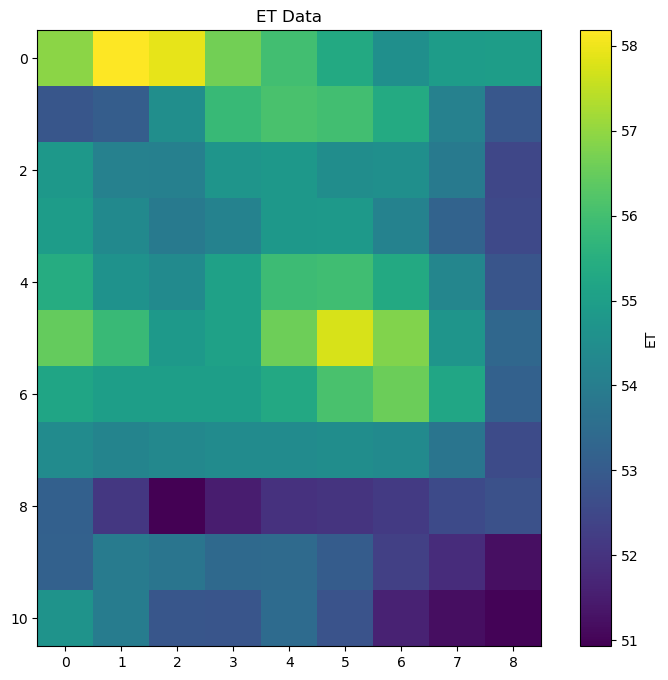

In [37]:
#this plot was cross-referenced with data in QGIS to ensure the areas matched up correctly
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(beam)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [38]:
#set the geometry to the actual boundaries of New Mexico
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

In [39]:
if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]

new_mexico.ndim

2

In [42]:
#set any values above 32700 to null
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

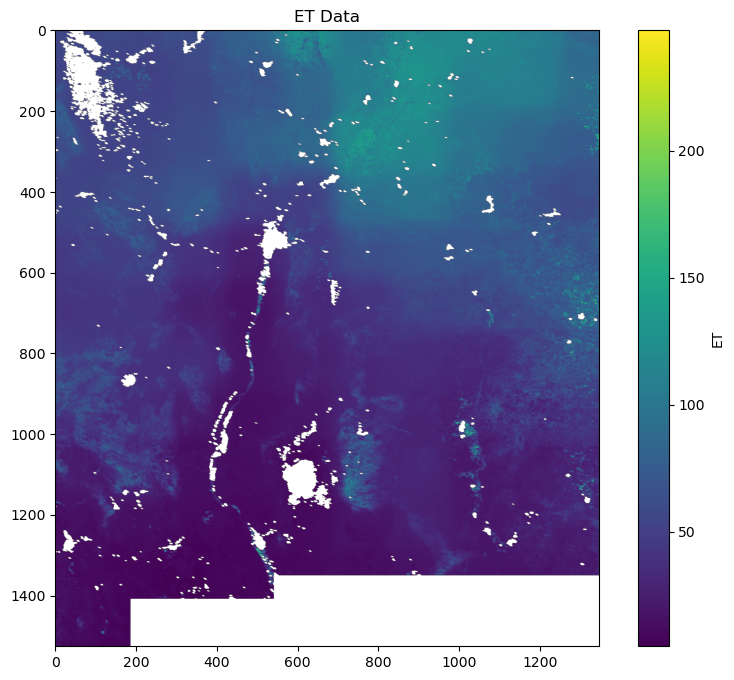

In [43]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [44]:
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

Choose a year and month (format YYYYMM) 202208


['MOD16A2_MERGED_20220805_ET.tif', 'MOD16A2_MERGED_20220821_ET.tif', 'MOD16A2_MERGED_20220829_ET.tif', 'MOD16A2_MERGED_20220813_ET.tif']


Choose an ET threshold (I would recommend a threshold between 50 and 150) 100


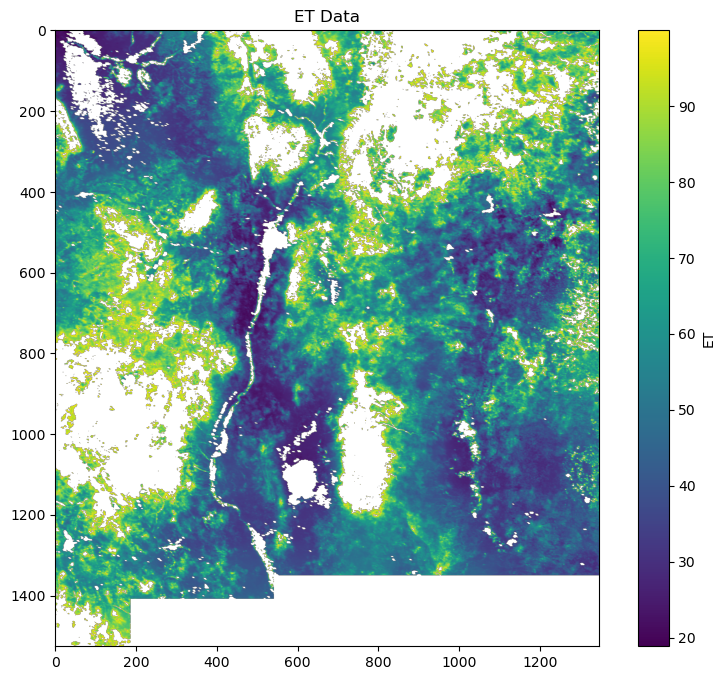

In [45]:
#obtain monthly averages for any month between Jan. 2021 and Dec. 2024
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

print(monthly_files)

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
threshold = int(input("Choose an ET threshold (I would recommend a threshold between 50 and 150)"))
new_mexico = np.where(new_mexico >= threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85


 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


Choose a year and month (format YYYYMM) 202309
Choose an minimum ET threshold (type 0 if N/A) 0
Choose an maximum ET threshold (type 32700 if N/A) 100


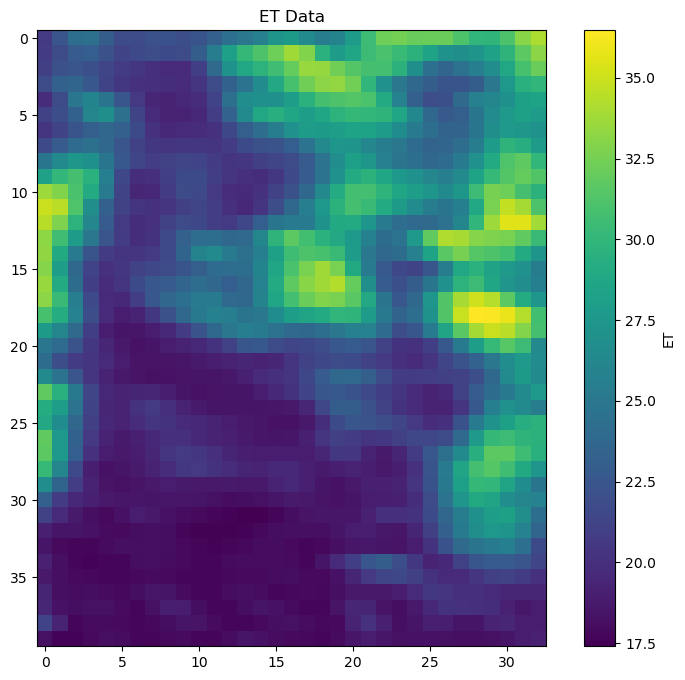

In [46]:
#plot monthly averages and allow the user to choose coordinates

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''
print(geometry)

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]
new_mexico = new_mexico * 0.00000001

monthly_files = []

month = int(input("Choose a year and month (format YYYYMM)"))
str_month = str(month)

for filename in all_files:
    if str_month in filename and "_ET" in filename and "MERGED" in filename:
        monthly_files.append(filename)

monthly_files

for file in monthly_files:
    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/' + file)
    new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico_2 = new_mexico_2[0, :, :]
    new_mexico += new_mexico_2

new_mexico /= len(monthly_files)
#print(new_mexico)

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = int(input("Choose an minimum ET threshold (type 0 if N/A)"))
max_threshold = int(input("Choose an maximum ET threshold (type 32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

'''pet_files = []

for filename in all_files:
    if "202405" in filename and "PET" in filename:
        pet_files.append(filename)

pet_data = np.zeros((2725, 8496))

for file in pet_files:
    test_path = "/Applications/MODIS_S3_downloads/" + file
    with rasterio.open(test_path) as src:
        pet_data += src.read(1)
        pet_data = np.where(pet_data >= 32700, np.nan, pet_data)
        #print(data)

pet_data /= len(pet_files)
print(pet_data)'''

#each ET or PET file is an 8 day average
'''esi_data = data/pet_data
esi_data = np.where(esi_data >= 0.1, np.nan, esi_data)
print(esi_data)'''

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


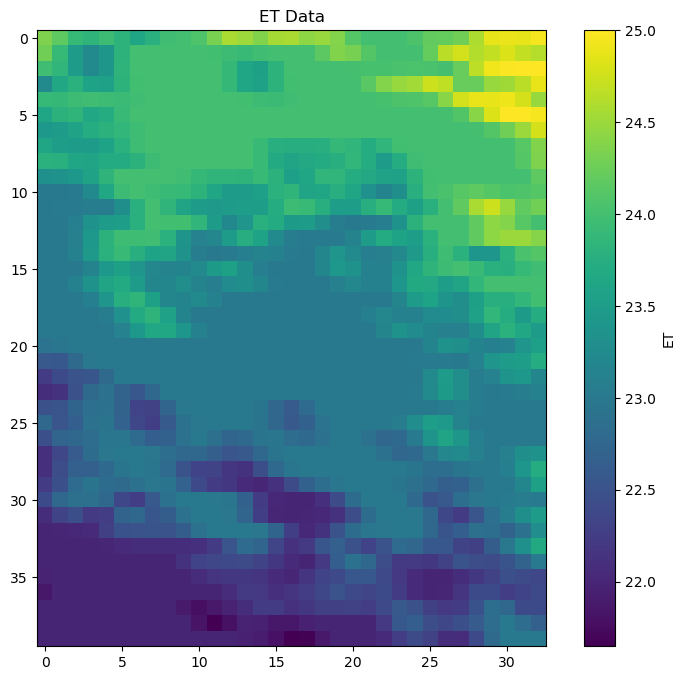

In [49]:
#test coordinate algorithm for single merged TIF file to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20241210_ET.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

[[nan nan nan ... 53. 53. 53.]
 [nan nan nan ... 53. 47. 47.]
 [nan nan nan ... 53. 47. nan]
 ...
 [nan 49. 53. ... nan nan nan]
 [nan 48. 48. ... nan nan nan]
 [55. 48. 53. ... nan nan nan]]


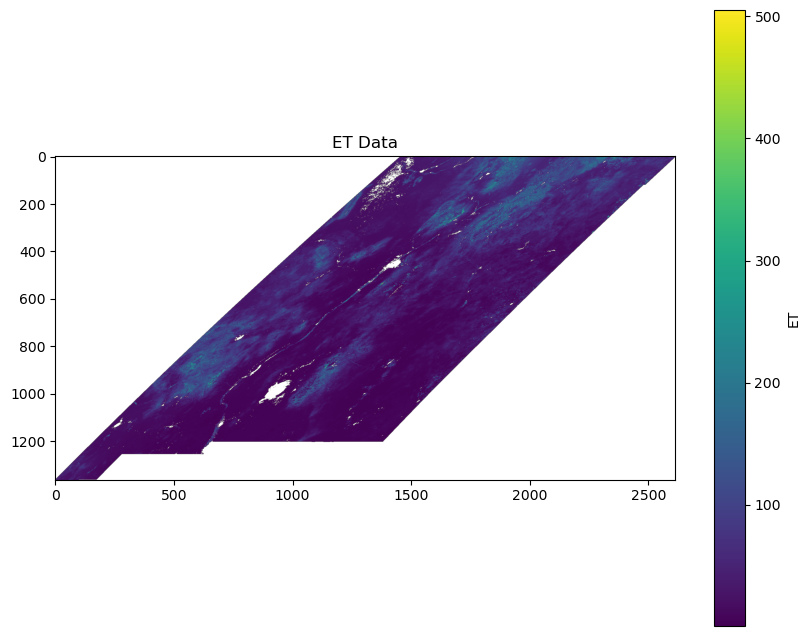

In [48]:
#plot data for a MODIS ET file downloaded from AppEEARS
test_path = "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024217000000_aid0001.tif"

with rasterio.open(test_path) as src:
    data = src.read(1)
    data = np.where(data >= 32700, np.nan, data)
    print(data)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(data)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


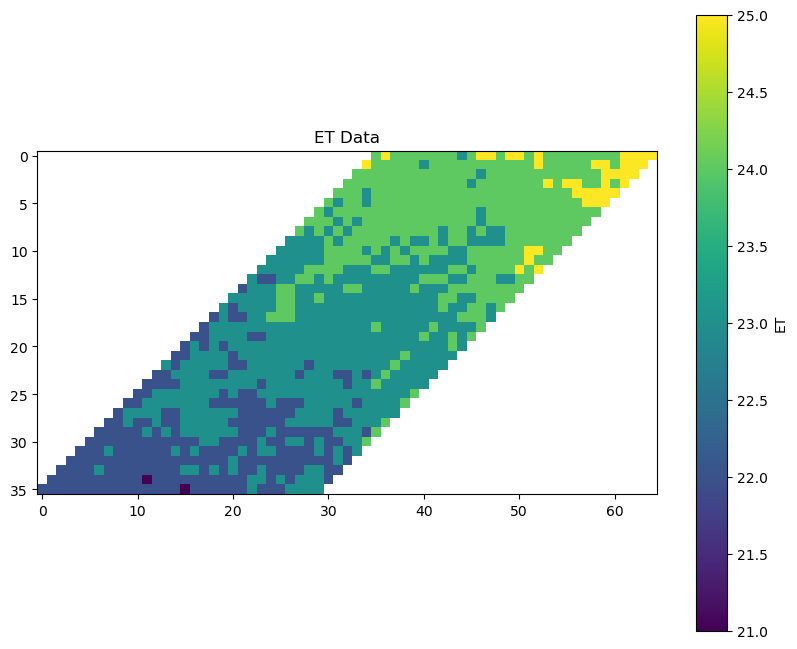

In [50]:
#test coordinate algorithm for single MODIS TIF file (downloaded directly from AppEEARS) to ensure it matches QGIS

coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024345000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

Choose a western boundary -104.31
Choose a southern boundary 33.7
Choose a eastern boundary -104.16
Choose a northern boundary 33.85
Choose an minimum ET threshold (0 if N/A) 0
Choose an maximum ET threshold (32700 if N/A) 100


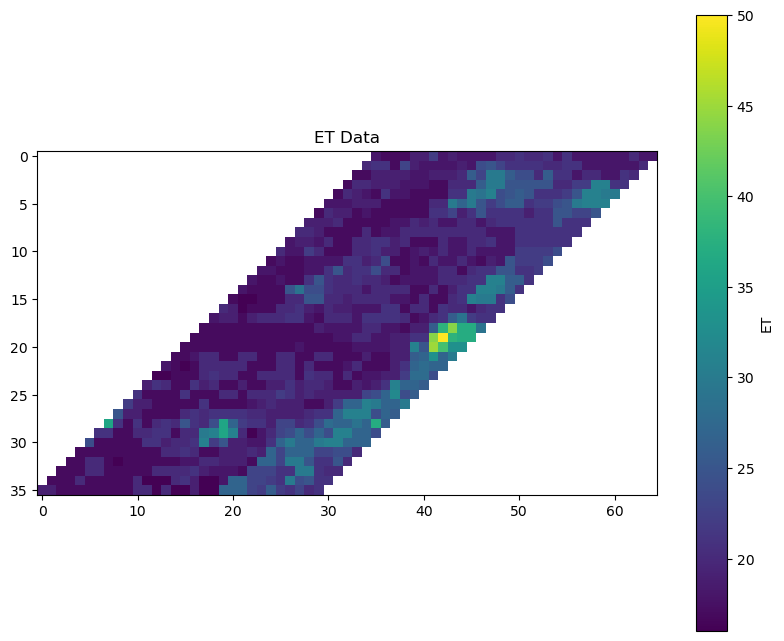

In [51]:
#collect data in user-specified boundaries for a specific ET file from 2005
coord1 = str(input("Choose a western boundary"))
coord2 = str(input("Choose a southern boundary"))
coord3 = str(input("Choose a eastern boundary"))
coord4 = str(input("Choose a northern boundary"))

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + coord1 + ''', ''' + coord2 + '''],
                [''' + coord1 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord4 + '''],
                [''' + coord3 + ''', ''' + coord2 + ']]]}'''

cropping_geometries = [geojson.loads(geometry)]

xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif')
#xds.rio.write_crs(4326, inplace=True)
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
new_mexico = new_mexico[0, :, :]

new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
min_threshold = float(input("Choose an minimum ET threshold (0 if N/A)"))
max_threshold = float(input("Choose an maximum ET threshold (32700 if N/A)"))
new_mexico = np.where(new_mexico < min_threshold, np.nan, new_mexico)
new_mexico = np.where(new_mexico > max_threshold, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

In [52]:
#datetime allows us to take the current date, set dates, and add/subtract dates
import datetime
from datetime import date, timedelta

The DroughtDetection class below provides a series of definitions that when combined, allow the user to come up with a customized map of ET data.

generate_tiffs(): collects files from the MODIS merged data (2021-2025) for range of dates relative to the current date
generate_static_tiffs(): collect files from the MODIS merged data (2021-2025) for a set range of dates
generate_et_tiffs(): collect files from MODIS ET data on NASA AppEEARS (2000-2024) for a set range of dates
find_stdev(): calculate the standard deviation for the files specified in generate_et_tiffs()
choose_coordinates(): allows the user to choose the coordinates to collect data for
generate_threshold(): allows the user to choose a min and max ET threshold and then plots a map of merged ET data (2021-2025) for the state of New Mexico
generate_threshold_coords(): same as generate_threshold() except generates a map for merged ET data within the coordinates specified in choose_coordinates()
generate_threshold_modis(): same as generate_threshold_coords() except generates a map for direct MODIS ET data (2000-2024) instead of merged ET data

In [ ]:
The Drought 

In [53]:
class DroughtDetection:
    def __init__(
            self, 
            geojson_file: str,
            date: datetime.date
    ):
        
        self.geojson_file = geojson_file #base of constructor
        self.date = date #base of constructor

    def generate_tiffs(self, start, end):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        current_date = date.today()
        start_date = current_date - timedelta(days=start) 

        while start_date <= current_date - timedelta(days=end):
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        return list_of_tiffs

    def generate_static_tiffs(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_' + date + '_ET.tif'))

        #current_date = date.today()
        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)
            
        return list_of_tiffs

    def generate_et_tiffs(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))

        def find_doy(date):
            date = date.replace("-", "")
            if date[4:6] == "01":
                day = int(date[6:8])
                if day<10:
                    date = date.replace(date[4:8], "00" + str(day))
                else:
                    date = date.replace(date[4:8], "0" + str(day))
            elif date[4:6] == "02":
                day = int(date[6:8])
                num = 31 + day
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "03":
                day = int(date[6:8])
                num = 59 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], "0" + str(num))
            elif date[4:6] == "04":
                day = int(date[6:8])
                num = 90 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                if num<100:
                    date = date.replace(date[4:8], "0" + str(num))
                else:
                    date = date.replace(date[4:8], str(num))
            elif date[4:6] == "05":
                day = int(date[6:8])
                num = 120 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "06":
                day = int(date[6:8])
                num = 151 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "07":
                day = int(date[6:8])
                num = 181 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "08":
                day = int(date[6:8])
                num = 212 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "09":
                day = int(date[6:8])
                num = 243 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "10":
                day = int(date[6:8])
                num = 273 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "11":
                day = int(date[6:8])
                num = 304 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            elif date[4:6] == "12":
                day = int(date[6:8])
                num = 334 + day
                if (int(date[2:4]))%4 == 0:
                    num+= 1
                date = date.replace(date[4:8], str(num))
            else:
                print("Invalid date.")
            return date

        #new_date = date(year, month, day)
        #new_date = str(new_date)
        #new_date = find_doy(new_date)
        #check_for_tiff(new_date)

        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = find_doy(string_date)
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        return list_of_tiffs

    def find_stdev(self, start_year, start_month, start_day, end_year, end_month, end_day):
        from rasterio import shutil

        list_of_tiffs = []

        def check_for_tiff(date):
            #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
            if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
                list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
        #current_date = date.today()
        start_date = date(start_year, start_month, start_day)
        end = date(end_year, end_month, end_day)

        while start_date <= end:
            string_date = str(start_date)
            string_date = find_doy(string_date)
            string_date = string_date.replace("-", "")
            check_for_tiff(string_date)
            start_date += timedelta(days=1)

        #print(list_of_tiffs)

        tiff_data = []

        def get_tiff_data(tiff):
            xds = rioxarray.open_rasterio(tiff)
            tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            tiff = tiff[0, :, :]
            #tiff = np.where(tiff >= 32700, np.nan, tiff)
            return tiff

        for tiff in list_of_tiffs:
            #print(np.shape(tiff))
            tiff_data.append(get_tiff_data(tiff))
            #tiff = np.where(tiff >= 32700, np.nan, tiff)

        #print(tiff_data)

        sd = tiff_data[0] * 0.0000001
        sum_sq = (tiff_data[0]) * 0.0000001
        sum_reg = tiff_data[0] * 0.0000001

        for tiff in tiff_data:   
            sum_reg += tiff
        
        mean = sum_reg/len(tiff_data)
    
        for tiff in tiff_data:
            sum_sq += (tiff-mean)**2

        #print(sum_sq)
    
        sd = ((sum_sq)/(len(tiff_data)-1))**0.5
        #print(sd)

        sd = np.where(sd < 1, np.nan, sd)

        import matplotlib.pyplot as plt
    
        plt.figure(figsize=(10,8))
        plt.imshow(sd)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def choose_coordinates(self, coord1, coord2, coord3, coord4):
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[''' + str(coord1) + ''', ''' + str(coord2) + '''],
                [''' + str(coord1) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord4) + '''],
                [''' + str(coord3) + ''', ''' + str(coord2) + ']]]}'''
        return geometry

    def generate_threshold(self, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def generate_threshold_coords(self, coords, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = coords

        cropping_geometries = [geojson.loads(geometry)]

        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        #xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
        new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(monthly_files)
            #print(new_mexico)

        new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = np.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = np.where(new_mexico > high, np.nan, new_mexico)

        plt.figure(figsize=(10,8))
        plt.imshow(new_mexico)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

    def generate_threshold_modis(self, coords, list_of_tiffs, low, high):
        #return threshold #get this code to run in jupyter notebook
        geometry = coords

        cropping_geometries = [geojson.loads(geometry)]

        #xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
        xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif')

        #new_mexico = None
        
        new_mexico = xds.copy().rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico = new_mexico[0, :, :]
        new_mexico = new_mexico * 0.00000001

        for tiff in list_of_tiffs:
            xds = rioxarray.open_rasterio(tiff)
            new_mexico_2 = xds.copy().rio.clip(geometries=cropping_geometries, crs=4326)
            new_mexico_2 = new_mexico_2[0, :, :]
            new_mexico += new_mexico_2

        new_mexico /= len(list_of_tiffs)

        '''for tiff in list_of_tiffs:
            data = rioxarray.open_rasterio(tiff)
            #data = data.copy()
            data = data.astype('float64')
            #data = data.rio.clip(geometries=cropping_geometries, crs=4326)
        if new_mexico is None:
            new_mexico = data
        else:
            new_mexico += data

        new_mexico /= len(list_of_tiffs)
            #print(new_mexico)'''

        new_mexico = xr.where(new_mexico >= 32700, np.nan, new_mexico)
        new_mexico = xr.where(new_mexico < low, np.nan, new_mexico)
        new_mexico = xr.where(new_mexico > high, np.nan, new_mexico)

        return new_mexico

    def plot(self, data):
        plt.figure(figsize=(10,8))
        plt.imshow(data)
        plt.colorbar(label='ET')
        plt.title('ET Data')
        return plt.show()

In [54]:
import datetime

model = DroughtDetection(
    geojson_file = "path/to/geojson",
    date = datetime.datetime.now()
)

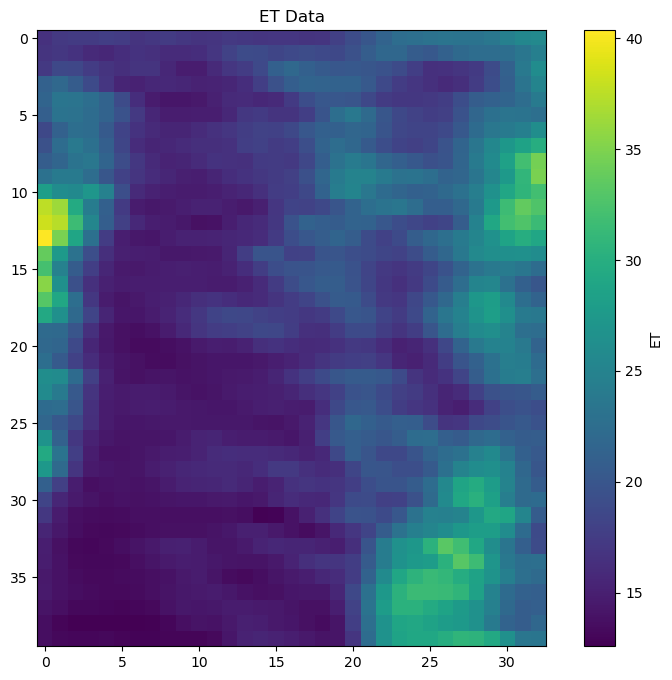

['/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240617_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240625_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240703_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240711_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240719_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240727_ET.tif', '/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20240804_ET.tif']
 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


In [55]:
#test some functions from DroughtDetection
list_of_tiffs = model.generate_static_tiffs(2024, 6, 17, 2024, 8, 4)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
model.generate_threshold_coords(coords, list_of_tiffs, 0, 100)
print(list_of_tiffs)
print(coords)

In [56]:
#another test of DroughtDetection functions

list_of_tiffs = model.generate_et_tiffs(2019, 3, 8, 2019, 4, 5)
print(list_of_tiffs)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
print(coords)
model.generate_threshold_modis(coords, list_of_tiffs, 0, 100)
#print(list_of_tiffs)

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019073000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019081000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2019089000000_aid0001.tif']
 {"type": "Polygon",
               "coordinates": [
                [[-104.31, 33.7],
                [-104.31, 33.85],
                [-104.16, 33.85],
                [-104.16, 33.7]]]}


<xarray.DataArray (y: 36, x: 65)> Size: 19kB
array([[        nan,         nan,         nan, ..., 32.00000007,
        31.33333339, 31.33333339],
       [        nan,         nan,         nan, ..., 31.33333339,
        32.3333334 ,         nan],
       [        nan,         nan,         nan, ..., 31.00000007,
                nan,         nan],
       ...,
       [        nan,         nan, 29.66666672, ...,         nan,
                nan,         nan],
       [        nan, 29.66666672, 29.66666672, ...,         nan,
                nan,         nan],
       [30.00000006, 29.66666673, 30.00000006, ...,         nan,
                nan,         nan]], shape=(36, 65))
Coordinates:
    band         int64 8B 1
  * x            (x) float64 520B -9.649e+06 -9.649e+06 ... -9.62e+06 -9.62e+06
  * y            (y) float64 288B 3.764e+06 3.763e+06 ... 3.748e+06 3.748e+06
    spatial_ref  int64 8B 0

In [52]:
#used this code cell to test the find_doy function used in DroughtDetection to convert between actual date and day of year

current_date = date.today() - timedelta(days=144)

current_date = str(current_date)

def find_doy(date):
    date = date.replace("-", "")
    if date[4:6] == "01":
        day = int(date[6:8])
        if day<10:
            date = date.replace(date[4:8], "00" + str(day))
        else:
            date = date.replace(date[4:8], "0" + str(day))
    elif date[4:6] == "02":
        day = int(date[6:8])
        num = 31 + day
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "03":
        day = int(date[6:8])
        num = 59 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "04":
        day = int(date[6:8])
        num = 90 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        if num<100:
            date = date.replace(date[4:8], "0" + str(num))
        else:
            date = date.replace(date[4:8], str(num))
    elif date[4:6] == "05":
        day = int(date[6:8])
        num = 120 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "06":
        day = int(date[6:8])
        num = 151 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "07":
        day = int(date[6:8])
        num = 181 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "08":
        day = int(date[6:8])
        num = 212 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "09":
        day = int(date[6:8])
        num = 243 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "10":
        day = int(date[6:8])
        num = 273 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "11":
        day = int(date[6:8])
        num = 304 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "12":
        day = int(date[6:8])
        num = 334 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    else:
        print("Invalid date.")
    return date

find_doy("2024-07-31")

'2024213'

In [53]:
#no need to run this code
start_date = date(2024,10,21)
end = date(2024,11,16)

while start_date <= end:
    string_date = str(start_date)
    #string_date = find_doy(string_date)
    #check_for_tiff(string_date)
    start_date += timedelta(days=1)
    print(start_date)

2024-10-22
2024-10-23
2024-10-24
2024-10-25
2024-10-26
2024-10-27
2024-10-28
2024-10-29
2024-10-30
2024-10-31
2024-11-01
2024-11-02
2024-11-03
2024-11-04
2024-11-05
2024-11-06
2024-11-07
2024-11-08
2024-11-09
2024-11-10
2024-11-11
2024-11-12
2024-11-13
2024-11-14
2024-11-15
2024-11-16
2024-11-17


In [57]:
#this code cell does not run

geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

#cropping_geometries = [geojson.loads(geometry)]
#xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024305000000_aid0001.tif')
#new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

'''if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]
new_mexico.ndim
new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024313000000_aid0001.tif')
nm_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)

if nm_2.shape[0] == 1:
    nm_2 = nm_2[0, :, :]
nm_2.ndim
nm_2 = np.where(nm_2 >= 32700, np.nan, nm_2)

nm_3 = (new_mexico + nm_2)/2
sd = (new_mexico-nm_3)**2 + (nm_2-nm_3)**2
sd = sd**0.5

print(new_mexico)
print(nm_2)
print(nm_3)
print(sd)'''

def find_doy(date):
    date = date.replace("-", "")
    if date[4:6] == "01":
        day = int(date[6:8])
        if day<10:
            date = date.replace(date[4:8], "00" + str(day))
        else:
            date = date.replace(date[4:8], "0" + str(day))
    elif date[4:6] == "02":
        day = int(date[6:8])
        num = 31 + day
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "03":
        day = int(date[6:8])
        num = 59 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], "0" + str(num))
    elif date[4:6] == "04":
        day = int(date[6:8])
        num = 90 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        if num<100:
            date = date.replace(date[4:8], "0" + str(num))
        else:
            date = date.replace(date[4:8], str(num))
    elif date[4:6] == "05":
        day = int(date[6:8])
        num = 120 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "06":
        day = int(date[6:8])
        num = 151 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "07":
        day = int(date[6:8])
        num = 181 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "08":
        day = int(date[6:8])
        num = 212 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "09":
        day = int(date[6:8])
        num = 243 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "10":
        day = int(date[6:8])
        num = 273 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "11":
        day = int(date[6:8])
        num = 304 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    elif date[4:6] == "12":
        day = int(date[6:8])
        num = 334 + day
        if (int(date[2:4]))%4 == 0:
            num+= 1
        date = date.replace(date[4:8], str(num))
    else:
        print("Invalid date.")
    return date

def find_sd(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    #return sd

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd(2024, 1, 1, 2024, 12, 31)

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024001000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024009000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024017000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024025000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024033000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024041000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024049000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024057000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024065000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_

NoDataInBounds: No data found in bounds.

In [58]:
#find all the ET data TIFF files between July 31, 2002 and November 5, 2024
list_of_tiffs = model.generate_et_tiffs(2002, 7, 31, 2024, 11, 5)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_map = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_map

<xarray.DataArray (y: 36, x: 65)> Size: 19kB
array([[        nan,         nan,         nan, ..., 33.6555773 ,
        33.94911937, 33.74168297],
       [        nan,         nan,         nan, ..., 33.69960861,
        33.4295499 ,         nan],
       [        nan,         nan,         nan, ..., 33.17514677,
                nan,         nan],
       ...,
       [        nan,         nan, 30.16340509, ...,         nan,
                nan,         nan],
       [        nan, 29.73679061, 27.85127202, ...,         nan,
                nan,         nan],
       [27.93150685, 27.09099804, 27.18982387, ...,         nan,
                nan,         nan]], shape=(36, 65))
Coordinates:
    band         int64 8B 1
  * x            (x) float64 520B -9.649e+06 -9.649e+06 ... -9.62e+06 -9.62e+06
  * y            (y) float64 288B 3.764e+06 3.763e+06 ... 3.748e+06 3.748e+06
    spatial_ref  int64 8B 0

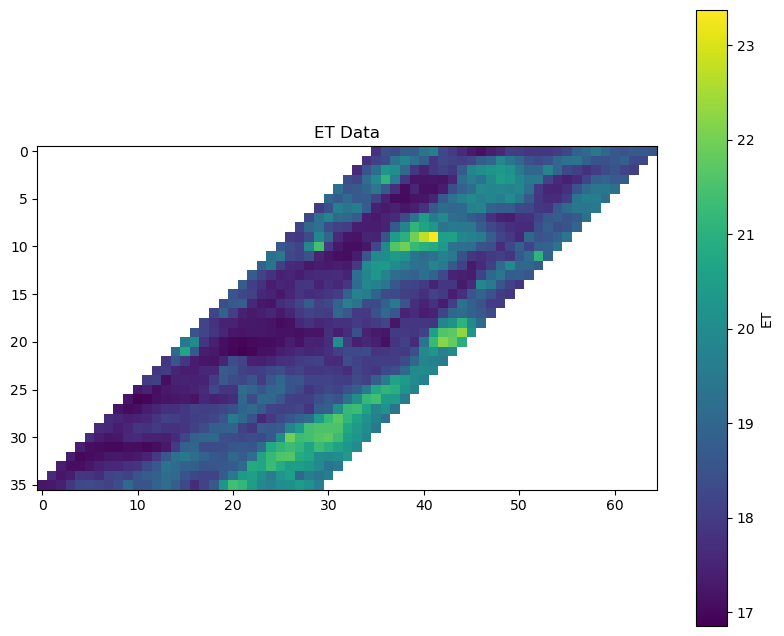

In [60]:
#find and plot the standard deviation between the aforementioned ET files for each pixel
et_stdev = model.find_stdev(2002, 7, 31, 2024, 11, 5)
et_stdev

In [61]:
#calculate and plot ET values one standard deviation above the mean between certain dates for each pixel (optional)
#currently does not work
def find_sd_plus(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    #print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    #print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    #print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
    new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico = new_mexico[0, :, :]
    new_mexico = new_mexico * 0.00000001

    for tiff in list_of_tiffs:
        xds = rioxarray.open_rasterio(tiff)
        new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico_2 = new_mexico_2[0, :, :]
        new_mexico += new_mexico_2

    new_mexico /= len(list_of_tiffs)
    
    new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

    sd += new_mexico

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_plus(2002, 7, 31, 2024, 11, 5)

NoDataInBounds: No data found in bounds.

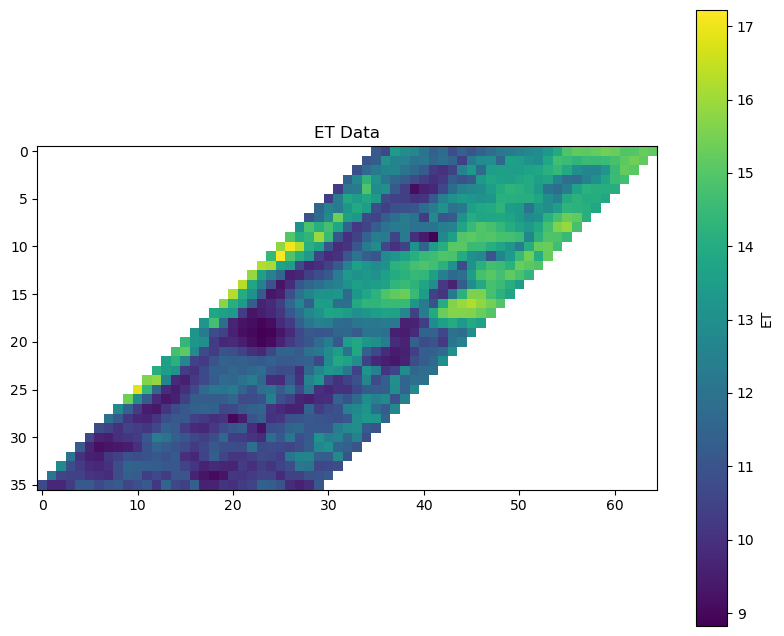

In [133]:
def find_sd_minus(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        string_date = str(start_date)
        string_date = find_doy(string_date)
        string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    #print(list_of_tiffs)

    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    #print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    #print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    sd *= -1

    xds = rioxarray.open_rasterio('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024321000000_aid0001.tif')
    new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)
    new_mexico = new_mexico[0, :, :]
    new_mexico = new_mexico * 0.00000001

    for tiff in list_of_tiffs:
        xds = rioxarray.open_rasterio(tiff)
        new_mexico_2 = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        new_mexico_2 = new_mexico_2[0, :, :]
        new_mexico += new_mexico_2

    new_mexico /= len(list_of_tiffs)
    
    new_mexico = np.where(new_mexico >= 32700, np.nan, new_mexico)

    sd += new_mexico

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_minus(2002, 7, 31, 2024, 11, 5)

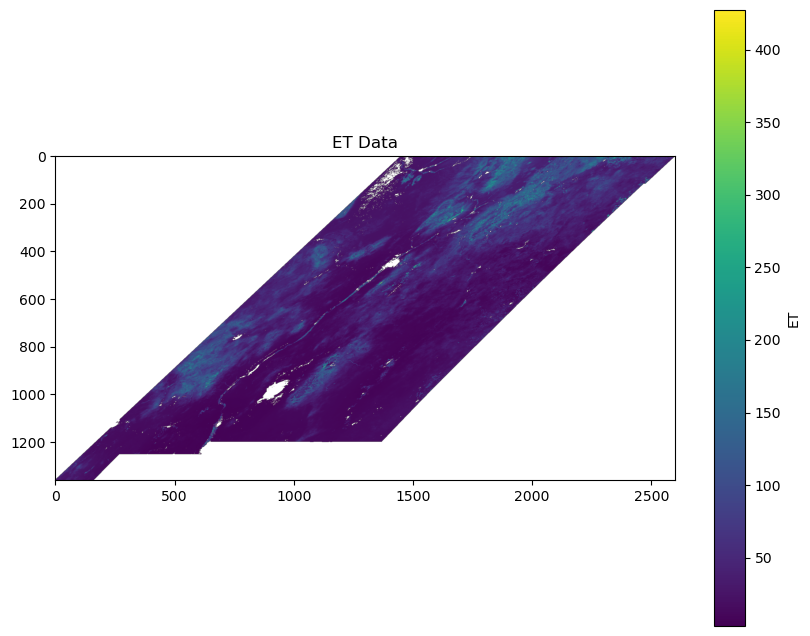

In [62]:
list_of_tiffs = model.generate_et_tiffs(2024, 7, 31, 2024, 8, 31)
#print(list_of_tiffs)
#coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
coords = model.choose_coordinates(-109, 31.333, -103, 37)
et_map_2024 = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_plot = model.plot(et_map_2024)

In [65]:
list_of_tiffs = model.generate_et_tiffs(2000, 11, 1, 2000, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2001, 11, 1, 2001, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2002, 11, 1, 2002, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2003, 11, 1, 2003, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2004, 11, 1, 2004, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2005, 11, 1, 2005, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2006, 11, 1, 2006, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2007, 11, 1, 2007, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2008, 11, 1, 2008, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2009, 11, 1, 2009, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2010, 11, 1, 2010, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2011, 11, 1, 2011, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2012, 11, 1, 2012, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2013, 11, 1, 2013, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2014, 11, 1, 2014, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2015, 11, 1, 2015, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2016, 11, 1, 2016, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2017, 11, 1, 2017, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2018, 11, 1, 2018, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2019, 11, 1, 2019, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2020, 11, 1, 2020, 11, 30)
list_of_tiffs = model.generate_et_tiffs(2021, 11, 1, 2021, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2022, 11, 1, 2022, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2023, 11, 1, 2023, 11, 30)
list_of_tiffs += model.generate_et_tiffs(2024, 11, 1, 2024, 11, 30)
coords = model.choose_coordinates(-104.31, 33.7, -104.16, 33.85)
et_map = model.generate_threshold_modis(coords, list_of_tiffs, 0, 10000)
et_map_plot = model.plot(et_map)
et_map_plot

NoDataInBounds: No data found in bounds.

[array([[nan, nan, nan, ...,  9., 12.,  9.],
       [nan, nan, nan, ...,  8., 13., nan],
       [nan, nan, nan, ...,  9., nan, nan],
       ...,
       [nan, nan,  4., ..., nan, nan, nan],
       [nan,  3.,  4., ..., nan, nan, nan],
       [ 4.,  8.,  4., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ...,  7.,  6.,  6.],
       [nan, nan, nan, ...,  6.,  7., nan],
       [nan, nan, nan, ...,  6., nan, nan],
       ...,
       [nan, nan,  3., ..., nan, nan, nan],
       [nan,  3.,  3., ..., nan, nan, nan],
       [ 3.,  3.,  3., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ...,  3.,  3.,  3.],
       [nan, nan, nan, ...,  3.,  6., nan],
       [nan, nan, nan, ...,  3., nan, nan],
       ...,
       [nan, nan,  2., ..., nan, nan, nan],
       [nan,  2.,  2., ..., nan, nan, nan],
       [ 2.,  2.,  2., ..., nan, nan, nan]], shape=(36, 65)), array([[nan, nan, nan, ..., 34., 45., 39.],
       [nan, nan, nan, ..., 33., 36., nan],
       [nan, nan, nan, ..., 3

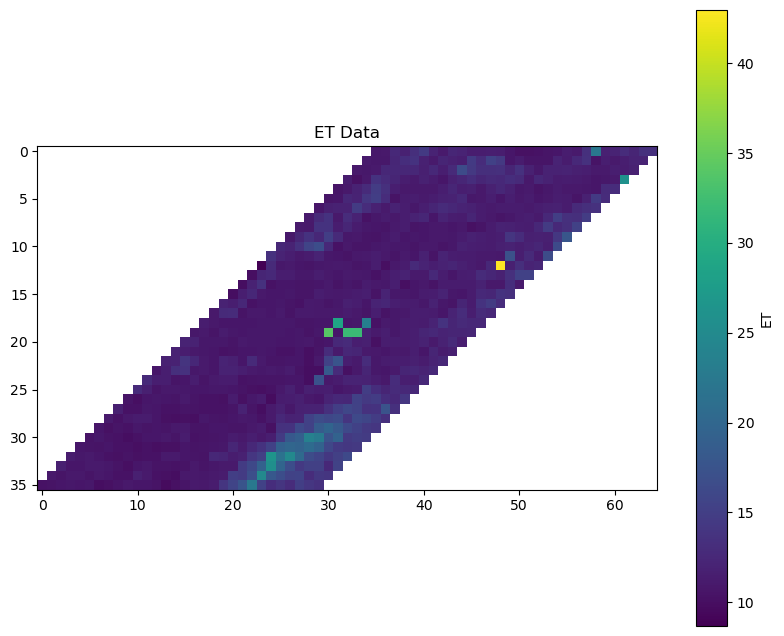

In [157]:
#use this after running the slide above
#currently does not work -- skip for now

def find_sd_of_tiffs(list_of_tiffs):
    tiff_data = []

    def get_tiff_data(tiff):
        xds = rioxarray.open_rasterio(tiff)
        tiff = xds.rio.clip(geometries=cropping_geometries, crs=4326)
        tiff = tiff[0, :, :]
        tiff = np.where(tiff >= 32700, np.nan, tiff)
        return tiff

    for tiff in list_of_tiffs:
        #print(np.shape(tiff))
        tiff_data.append(get_tiff_data(tiff))
        #tiff = np.where(tiff >= 32700, np.nan, tiff)

    print(tiff_data)

    sd = tiff_data[0] * 0.0000001
    sum_sq = (tiff_data[0]) * 0.0000001
    sum_reg = tiff_data[0] * 0.0000001

    for tiff in tiff_data:   
        sum_reg += tiff
        
    mean = sum_reg/len(tiff_data)
    
    for tiff in tiff_data:
        sum_sq += (tiff-mean)**2

    #print(sum_sq)
    
    sd = ((sum_sq)/(len(tiff_data)-1))**0.5
    print(sd)

    sd = np.where(sd < 1, np.nan, sd)

    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(10,8))
    plt.imshow(sd)
    plt.colorbar(label='ET')
    plt.title('ET Data')
    return plt.show()

find_sd_of_tiffs(list_of_tiffs)

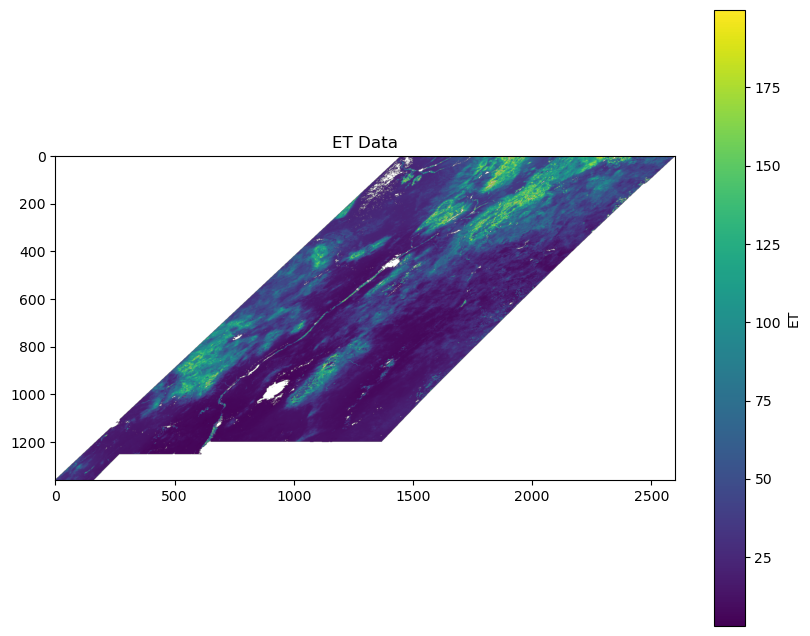

'et_test = xr.DataArray(\n    data=et_test.data,\n    dims=ref.dims,\n    coords=ref.coords,\n    attrs=ref.attrs\n)\n\net_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test_mar2124_B.tif")'

In [63]:
#plot July ET averages between 2021 and 2024 -- commented blocks of code are a failed attempt to download a new TIFF file

test_data = model.generate_et_tiffs(2021, 7, 1, 2021, 7, 31)
test_data += model.generate_et_tiffs(2022, 7, 1, 2022, 7, 31)
test_data += model.generate_et_tiffs(2023, 7, 1, 2023, 7, 31)
test_data += model.generate_et_tiffs(2024, 7, 1, 2024, 7, 31)
coords = model.choose_coordinates(-109, 31.333, -103, 37)
et_map = model.generate_threshold_modis(coords, list_of_tiffs, 0, 200)
et_map_plot = model.plot(et_map)
et_map_plot

'''import xarray as xr
import rioxarray

ref = rioxarray.open_rasterio(
    "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif"
)

et_test = ref.data'''

'''et_test = xr.DataArray(
    data=et_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)

et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_mar_2021_2024_copy_2.tif")'''

'''et_test = xr.DataArray(
    data=et_test.data,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs
)

et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test_mar2124_B.tif")'''


# Now attach the rioxarray metadata
#et_test.rio.write_crs(ref.rio.crs, inplace=True)
#et_test.rio.write_transform(ref.rio.transform(), inplace=True)

# Save
#et_test.rio.to_raster("/Users/ryanjoshi/Downloads/et_test.tif")


In [64]:
#currently does not work
test_sds = find_sd_of_tiffs(test_data)
test_sds.rasterio.to_raster("/Users/ryanjoshi/Downloads/nm_test_sds.tif")

NameError: name 'find_sd_of_tiffs' is not defined

(1526, 1347)


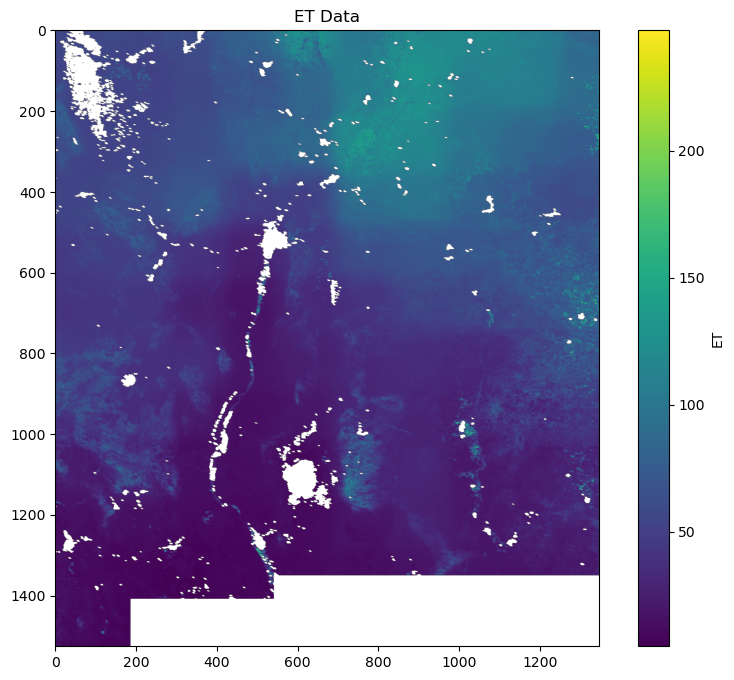

CoordinateValidationError: conflicting sizes for dimension 'y': length 1526 on the data but length 1362 on coordinate 'y'

In [65]:
#returns a map but returns an error after the map
geometry = ''' {"type": "Polygon",
               "coordinates": [
                [[-109.05, 31.333],
                [-109.045, 36.999],
                 [-103, 36.999],
                [-103, 32.002],
                [-106.618, 32.002],
                [-106.618, 31.781],
                [-108.210, 31.781],
                [-108.210, 31.333]]]}'''

cropping_geometries = [geojson.loads(geometry)]
xds = rioxarray.open_rasterio('/Users/ryanjoshi/Desktop/MODIS S3 downloads/MOD16A2_MERGED_20250501_ET.tif')
new_mexico = xds.rio.clip(geometries=cropping_geometries, crs=4326)

if new_mexico.shape[0] == 1:
    new_mexico = new_mexico[0, :, :]

print(new_mexico.shape)
new_mexico.ndim

new_mexico = xr.where(new_mexico >= 32700, np.nan, new_mexico)

import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
plt.imshow(new_mexico)
plt.colorbar(label='ET')
plt.title('ET Data')
plt.show()

import xarray as xr
import rioxarray

ref = rioxarray.open_rasterio(
    "/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2005089000000_aid0001.tif"
)

# If you manually built et_test from numpy:
new_mexico = xr.DataArray(
    data=new_mexico,  # the final combined data
    dims=("y", "x"),
    coords={
        #"band": [1],
        "y": ref.y,
        "x": ref.x
    },
    attrs=ref.attrs
)
#new_mexico = new_mexico[0,:,:]

# Now attach the rioxarray metadata
new_mexico.rio.write_crs(ref.rio.crs, inplace=True)
new_mexico.rio.write_transform(ref.rio.transform(), inplace=True)

# Save
new_mexico.rio.to_raster("/Users/ryanjoshi/Downloads/test_download_may_first.tif")


et_test = ref.data

et_test = xr.DataArray(
    data=et_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)

et_test.rio.to_raster("/Users/ryanjoshi/Downloads/test_download.tif")

In [72]:
#downloads a TIFF file by combining ET TIFF files (i.e. July ET average from 2021-2024)

import xarray as xr
import rioxarray

def find_tiffs(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'))

    def find_doy(year, month, day):
        date_obj = datetime.datetime(year, month, day)
        day_of_year = date_obj.strftime("%j")
        return day_of_year
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        print(start_date)
        year = start_date.year
        month = start_date.month
        day = start_date.day
        doy = find_doy(year, month, day)
        string_date = str(start_date)
        string_date = string_date[0:4] + str(doy)
        print(string_date)
        #string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    print(list_of_tiffs)
    return list_of_tiffs

list_of_tiffs = find_tiffs(2021, 7, 1, 2021, 7, 31)
list_of_tiffs += find_tiffs(2022, 7, 1, 2022, 7, 31)
list_of_tiffs += find_tiffs(2023, 7, 1, 2023, 7, 31)
list_of_tiffs += find_tiffs(2024, 7, 1, 2024, 7, 31)

reef = rioxarray.open_rasterio(
    '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024217000000_aid0001.tif'
)

et_test = reef.data
et_test = et_test.astype('float64')
et_test *= 0.0000001

for file in list_of_tiffs:
    ref = rioxarray.open_rasterio(file)
    et_test += ref.data

'''et_test = ref.data
et_test += ref2.data
et_test += ref3.data
et_test += ref4.data
et_test = et_test.astype('float64')'''
et_test /= len(list_of_tiffs)

et_test = xr.DataArray(
    data=et_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)

et_test.rio.to_raster("/Users/ryanjoshi/Downloads/july_2021_to_2024_et_ACTUAL_2.tif")

2021-07-01
2021182
2021-07-02
2021183
2021-07-03
2021184
2021-07-04
2021185
2021-07-05
2021186
2021-07-06
2021187
2021-07-07
2021188
2021-07-08
2021189
2021-07-09
2021190
2021-07-10
2021191
2021-07-11
2021192
2021-07-12
2021193
2021-07-13
2021194
2021-07-14
2021195
2021-07-15
2021196
2021-07-16
2021197
2021-07-17
2021198
2021-07-18
2021199
2021-07-19
2021200
2021-07-20
2021201
2021-07-21
2021202
2021-07-22
2021203
2021-07-23
2021204
2021-07-24
2021205
2021-07-25
2021206
2021-07-26
2021207
2021-07-27
2021208
2021-07-28
2021209
2021-07-29
2021210
2021-07-30
2021211
2021-07-31
2021212
['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021185000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021193000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021201000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021209000000_aid0001.tif'

In [69]:
#testing ESI calculation by taking ET and PET for a single raster and dividing them to calculate ESI
import xarray as xr
import rioxarray

reef = rioxarray.open_rasterio(
    '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024217000000_aid0001.tif'
)

ref = rioxarray.open_rasterio(
    '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy2024217000000_aid0001.tif'
)

pet_test = reef.data
pet_test = pet_test.astype('float64')
pet_test /= ref.data

pet_test = xr.DataArray(
    data=pet_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)

pet_test.rio.to_raster("/Users/ryanjoshi/Downloads/esi_2024217.tif")

In [70]:
#downloads a TIFF file by combining ESI TIFF files (i.e. September ESI average from 2000-2024)
import xarray as xr
import rioxarray

def find_tiffs_for_esi(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif')):
            et = '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy' + date + '000000_aid0001.tif'
            list_of_tiffs.append(et)
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy' + date + '000000_aid0001.tif')):
            pet = '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy' + date + '000000_aid0001.tif'
            list_of_tiffs.append(pet)
        
    def find_doy(year, month, day):
        date_obj = datetime.datetime(year, month, day)
        day_of_year = date_obj.strftime("%j")
        return day_of_year
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        #print(start_date)
        year = start_date.year
        month = start_date.month
        day = start_date.day
        doy = find_doy(year, month, day)
        string_date = str(start_date)
        string_date = str(year) + str(doy)
        #print(string_date)
        #string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    #print(list_of_tiffs)
    return list_of_tiffs

#find_tiffs_for_esi(2021, 7, 1, 2021, 7, 31)
list_of_tiffs += find_tiffs_for_esi(2000, 9, 1, 2000, 9, 30)

year = 2001

while year <= 2024:
    list_of_tiffs += find_tiffs_for_esi(year, 9, 1, year, 9, 30)
    year += 1

print(list_of_tiffs)

esi_files = []

i = 1

while i < len(list_of_tiffs):
    #ref = rioxarray.open_rasterio(file)
    et_tiff = rioxarray.open_rasterio(list_of_tiffs[i-1]).data
    et_tiff = et_tiff.astype('float64')
    et_tiff = xr.where(et_tiff >= 32700, float("nan"), et_tiff)
    pet_tiff = rioxarray.open_rasterio(list_of_tiffs[i]).data
    pet_tiff = pet_tiff.astype('float64')
    pet_tiff = xr.where(pet_tiff <= 0.0000001, float("nan"), pet_tiff)
    pet_tiff = xr.where(pet_tiff >= 32700, float("nan"), pet_tiff)
    esi_file = et_tiff * 1/pet_tiff
    esi_files.append(esi_file)
    #print(et_tiff)
    #print(pet_tiff)
    i+=2
    #et_test += ref.data

esi_files 

reef = rioxarray.open_rasterio(
    '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2024217000000_aid0001.tif'
)

et_test = reef.data

et_test = xr.DataArray(
    data=et_test,
    dims=("band", "y", "x"),
    coords={
        "band": [1],
        "y": reef.y,
        "x": reef.x
    },
    attrs=reef.attrs
)

et_test.rio.write_crs(reef.rio.crs, inplace=True)
et_test.rio.write_transform(reef.rio.transform(), inplace=True)

et_test = et_test.astype('float64')
et_test *= 0.0000001

for file in esi_files:
    ref = file
    et_test += ref

'''et_test = ref.data
et_test += ref2.data
et_test += ref3.data
et_test += ref4.data
et_test = et_test.astype('float64')'''
et_test /= len(esi_files)

'''et_test = xr.DataArray(
    data=et_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)'''

print(len(esi_files))
print(et_test)
et_test.rio.to_raster("/Users/ryanjoshi/Downloads/september_esi_test_3.tif")

['/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021185000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021193000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021201000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2021209000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2022185000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2022193000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2022201000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2022209000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_doy2023185000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MODIS_ET_2000_to_2024/MOD16A2GF.061_ET_500m_

In [71]:
#downloads a TIFF file by combining PET TIFF files (i.e. July PET average from 2021-2024)
import xarray as xr
import rioxarray

def find_tiffs_pet(start_year, start_month, start_day, end_year, end_month, end_day):
    from rasterio import shutil

    list_of_tiffs = []

    def check_for_tiff(date):
        #xds = rioxarray.open_rasterio('/Applications/MODIS_S3_downloads/MOD16A2_MERGED_' + date + '_ET.tif')
        if rasterio.shutil.exists(('/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy' + date + '000000_aid0001.tif')):
            list_of_tiffs.append(('/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy' + date + '000000_aid0001.tif'))

    def find_doy(year, month, day):
        date_obj = datetime.datetime(year, month, day)
        day_of_year = date_obj.strftime("%j")
        return day_of_year
    
    #current_date = date.today()
    start_date = date(start_year, start_month, start_day)
    end = date(end_year, end_month, end_day)

    while start_date <= end:
        print(start_date)
        year = start_date.year
        month = start_date.month
        day = start_date.day
        doy = find_doy(year, month, day)
        string_date = str(start_date)
        string_date = string_date[0:4] + str(doy)
        print(string_date)
        #string_date = string_date.replace("-", "")
        check_for_tiff(string_date)
        start_date += timedelta(days=1)

    print(list_of_tiffs)
    return list_of_tiffs

list_of_tiffs = find_tiffs_pet(2021, 7, 1, 2021, 7, 31)
list_of_tiffs += find_tiffs_pet(2022, 7, 1, 2022, 7, 31)
list_of_tiffs += find_tiffs_pet(2023, 7, 1, 2023, 7, 31)
list_of_tiffs += find_tiffs_pet(2024, 7, 1, 2024, 7, 31)

reef = rioxarray.open_rasterio(
    '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy2024217000000_aid0001.tif'
)

pet_test = reef.data
pet_test = pet_test.astype('float64')
pet_test *= 0.0000001

for file in list_of_tiffs:
    ref = rioxarray.open_rasterio(file)
    pet_test += ref.data

'''et_test = ref.data
et_test += ref2.data
et_test += ref3.data
et_test += ref4.data
et_test = et_test.astype('float64')'''
pet_test /= len(list_of_tiffs)

pet_test = xr.DataArray(
    data=pet_test,
    dims=ref.dims,
    coords=ref.coords,
    attrs=ref.attrs)

pet_test.rio.to_raster("/Users/ryanjoshi/Downloads/july_2021_to_2024_pet_2.tif")

2021-07-01
2021182
2021-07-02
2021183
2021-07-03
2021184
2021-07-04
2021185
2021-07-05
2021186
2021-07-06
2021187
2021-07-07
2021188
2021-07-08
2021189
2021-07-09
2021190
2021-07-10
2021191
2021-07-11
2021192
2021-07-12
2021193
2021-07-13
2021194
2021-07-14
2021195
2021-07-15
2021196
2021-07-16
2021197
2021-07-17
2021198
2021-07-18
2021199
2021-07-19
2021200
2021-07-20
2021201
2021-07-21
2021202
2021-07-22
2021203
2021-07-23
2021204
2021-07-24
2021205
2021-07-25
2021206
2021-07-26
2021207
2021-07-27
2021208
2021-07-28
2021209
2021-07-29
2021210
2021-07-30
2021211
2021-07-31
2021212
['/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy2021185000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy2021193000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy2021201000000_aid0001.tif', '/Users/ryanjoshi/Downloads/MOD16_PET_QC_2000_to_2024/MOD16A2GF.061_PET_500m_doy202120

No need to run anything below here, this is all experimental. 

In [78]:
import xarray as xr
import rioxarray

#reef = xr.open_dataset("/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json", engine = "netcdf4")
reef = "/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data"

#test = reef.data
#test = pet_test.astype('float64')
#pet_test /= len(list_of_tiffs)

test = xr.Dataset(
    {"usdm_data": (("x", "y"), np.random.rand(4, 5))},
    coords={
        "x": [10, 20, 30, 40],
        "y": pd.date_range("2000-01-01", "2004-12-31", periods=5),
        "z": ("x", list("abcd")),
    },
)

import os

var_name = os.path.basename(reef)  # gets 'usdm_data'
test = xr.Dataset(
    {var_name: (("x", "y"), np.random.rand(4, 5))},
    coords={
        "x": [10, 20, 30, 40],
        "y": pd.date_range("2000-01-01", "2004-12-31", periods=5),
        "z": ("x", list("abcd")),
    },
)

test.to_netcdf("/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/myfile.nc")
#test.rio.to_raster("/Users/ryanjoshi/Downloads/drought_20190917.json")

In [85]:
import xarray as xr
import geopandas as gpd

gdf = gpd.read_file("/Users/ryanjoshi/Documents/GitHub/testrepo/usdm_data/usdm_20190917.json")

# Drop geometry column to create xarray dataset from attribute table
ds = xr.Dataset.from_dataframe(gdf.drop(columns='geometry'))

import geopandas as gpd
import rasterio
from rasterio.features import rasterize
from affine import Affine
import numpy as np

# Read the GeoJSON 
gdf = gpd.read_file("usdm_20190917.json")

# Define your raster grid
transform = Affine(0.1, 0, -125, 0, -0.1, 50)  # (pixel width, 0, west, 0, -pixel height, north)
out_shape = (100, 100)  # rows, cols

# Rasterize (burn the OBJECTID or similar field)
raster = rasterize(
    [(geom, value) for geom, value in zip(gdf.geometry, gdf["OBJECTID"])],
    out_shape=out_shape,
    transform=transform,
    fill=0,
    dtype='int16'
)

# Convert raster to xarray
ds = xr.DataArray(raster, dims=("y", "x")).to_dataset(name="usdm_zone")

ImportError: The 'read_file' function requires the 'pyogrio' or 'fiona' package, but neither is installed or imports correctly.
Importing pyogrio resulted in: dlopen(/usr/local/Caskroom/mambaforge/base/lib/python3.10/site-packages/pyogrio/_vsi.cpython-310-darwin.so, 0x0002): Symbol not found: _sqlite3_total_changes64
  Referenced from: <B80B434E-176E-3C98-8515-D041567396A3> /usr/local/Caskroom/mambaforge/base/lib/libgdal.36.3.10.0.dylib
  Expected in:     <AC0B8765-9768-3BC2-9A92-839074396253> /usr/local/Caskroom/mambaforge/base/lib/libsqlite3.0.dylib
Importing fiona resulted in: No module named 'fiona'

In [86]:
!pip install fiona

TypeError: unsupported operand type(s) for -: 'list' and 'list'

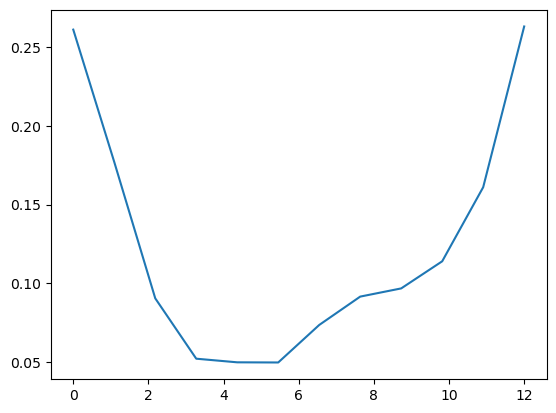

In [78]:
N = 21
x = np.linspace(0, 12, 12)
y = [0.261, 0.177, 0.0905, 0.0522, 0.0499, 0.0498, 0.0736,  0.0916, 0.0968, 0.114, 0.161, 0.263]

# fit a linear curve and estimate its y-values and their error.
#a, b = np.polyfit(x, y, deg=1)
#y_est = a * x + b
y_err = [0.101, 0.0811, 0.0448, 0.0276, 0.0307, 0.0408, 0.0505, 0.0534, 0.0414, 0.0277, 0.0385, 0.0884]

fig, ax = plt.subplots()
ax.plot(x, y, '-')
ax.fill_between(x, y - y_err, y + y_err)
ax.plot(x, y, 'o', color='tab:brown')
